# MedSAM — Ablation Study y Especialización Lumbar
## Modelos G1, H, I

| Modelo | Arquitectura | Preproc | Loss | Región |
|--------|-------------|---------|------|--------|
| **G**  | MedSAM | Curva+CLAHE | DiceBCE estándar | Global |
| **G1** | MedSAM | ❌ Sin preproc | DiceBCE estándar | Global |
| **H**  | MedSAM | Curva+CLAHE | Focal Loss L5 ponderada | Global |
| **I**  | MedSAM | Curva+CLAHE | Focal Loss L5 ponderada | Global + crop lumbar |

### Preguntas de investigación
- **G vs G1:** ¿Cuánto aporta el preprocesamiento espinal con curvas sobre MedSAM?
- **G vs H:** ¿Mejora L5 con Focal Loss sin degradar el Dice global?
- **H vs I:** ¿El crop lumbar aporta mejora adicional en L1-L5?

### Hipótesis
G supera a G1 → el preprocesamiento espinal tiene valor independiente de la arquitectura.
H supera a G en L5 → la Focal Loss ponderada corrige el sesgo hacia clases fáciles.
I supera a H en L1-L5 → mayor resolución efectiva en región lumbar mejora delimitación.

## 0 — Instalación y configuración

In [1]:
import os
if not os.path.exists('/content/MedSAM'):
    !git clone https://github.com/bowang-lab/MedSAM.git /content/MedSAM
    %cd /content/MedSAM
    !pip install -e . -q
else:
    %cd /content/MedSAM
    print('MedSAM ya clonado')

!pip install -q monai scikit-learn scipy gdown
import sys
sys.path.insert(0, '/content/MedSAM')

import torch
print(f'PyTorch: {torch.__version__} | CUDA: {torch.version.cuda}')
print(f'GPU:     {torch.cuda.get_device_name(0)}')
print(f'VRAM:    {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Cloning into '/content/MedSAM'...
remote: Enumerating objects: 967, done.
remote: Total 967 (delta 0), reused 0 (delta 0), pack-reused 967 (from 1)
Receiving objects: 100% (967/967), 62.91 MiB | 13.44 MiB/s, done.
Resolving deltas: 100% (475/475), done.
/content/MedSAM
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 157.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 135.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 101.9 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128 | CUDA: 12.8
GPU:     NVIDIA A100-SXM4-40GB
VRAM:    42.4 GB


In [2]:
MEDSAM_CKPT = '/content/medsam_vit_b.pth'
if not os.path.exists(MEDSAM_CKPT):
    !gdown 1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_ -O {MEDSAM_CKPT}
size_mb = os.path.getsize(MEDSAM_CKPT)/1e6
print(f'✔ Pesos: {size_mb:.1f} MB')
assert size_mb > 370, 'Descarga incompleta'

Downloading...
From (original): https://drive.google.com/uc?id=1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_
From (redirected): https://drive.google.com/uc?id=1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_&confirm=t&uuid=4859f0f7-57c2-4370-922d-3810c0941aeb
To: /content/medsam_vit_b.pth
100% 375M/375M [00:06<00:00, 59.9MB/s]
✔ Pesos: 375.0 MB


In [3]:
import warnings, random, json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.model_selection import train_test_split
from scipy.interpolate import UnivariateSpline
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch, torch.nn as nn
from segment_anything import sam_model_registry
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT   = Path('/content/drive/MyDrive')
DATASET_ROOT = DRIVE_ROOT / 'Scoliosis_Dataset'
CSV_PATH     = DATASET_ROOT / 'indice_dataset.csv'
METRICS_DIR  = DATASET_ROOT / 'RadiographMetrics'
CURVAS_DIR   = METRICS_DIR  / 'curvas_en_pixeles'
WORK_DIR     = Path('/content/medsam_ablation')
CKPT_DIR     = WORK_DIR / 'checkpoints'

# Cachés separados: con preproc y sin preproc
EMBED_CACHE_PREPROC   = WORK_DIR / 'embeddings_preproc'    # G, H, I
EMBED_CACHE_NOPREPROC = WORK_DIR / 'embeddings_nopreproc'  # G1

for d in [CKPT_DIR, EMBED_CACHE_PREPROC, EMBED_CACHE_NOPREPROC]:
    d.mkdir(parents=True, exist_ok=True)

COL_SPLIT  = 'split'
COL_IMAGE  = 'radiograph_path'
COL_MASK   = 'multiclass_id_png'
COL_BINARY = 'label_binary_path'

CLASS_NAMES = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10',
               'T11','T12','L1','L2','L3','L4','L5']
NUM_CLASSES = 17
LUMBAR_IDS  = list(range(12, 17))  # L1-L5
L5_ID       = 16
SEED        = 42
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'✔ Configuración lista | Device: {DEVICE}')

Mounted at /content/drive
✔ Configuración lista | Device: cuda


---
## 1 — Datos, curvas y filtrado

In [4]:
df = pd.read_csv(CSV_PATH, sep=';')
print(f'Total: {len(df)}')

CURVE_CACHE = {}
for _, row in df.iterrows():
    pid = int(row['patient_id'])
    p   = CURVAS_DIR / f'curva_pixeles_{pid}.csv'
    if p.exists():
        CURVE_CACHE[pid] = pd.read_csv(p)[['x_px','y_px']].values.astype(np.float32)
print(f'✔ Curvas: {len(CURVE_CACHE)}/{len(df)}')

def load_spine_curve(stem):
    m = df[df[COL_IMAGE].apply(lambda p: Path(p).stem == stem)]
    if len(m) == 0: return None
    return CURVE_CACHE.get(int(m.iloc[0]['patient_id']), None)

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df[COL_SPLIT], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df[COL_SPLIT], random_state=SEED)
for d in [train_df, val_df, test_df]: d.reset_index(drop=True, inplace=True)

def has_min_classes(mp, n=13):
    m = cv2.imread(str(mp), cv2.IMREAD_UNCHANGED)
    if m is None: return False
    if m.ndim==3: m=m[:,:,0]
    return all(i in set(int(v) for v in np.unique(m) if v>0) for i in range(1,n+1))

def filter_complete(df):
    return df[df[COL_MASK].apply(
        lambda p: has_min_classes(DATASET_ROOT/p))].reset_index(drop=True)

print('Filtrando...')
train_f = filter_complete(train_df)
val_f   = filter_complete(val_df)
test_f  = filter_complete(test_df)
print(f'Filtrado: Train={len(train_f)} Val={len(val_f)} Test={len(test_f)}')

Total: 249
✔ Curvas: 178/249
Filtrando...
Filtrado: Train=104 Val=24 Test=25


---
## 2 — Preprocesamiento espinal

In [5]:
def build_spine_probability_map(curve_pts, h, w, sigma_x=45):
    prob_map = np.zeros((h,w), dtype=np.float32)
    pts = curve_pts[np.argsort(curve_pts[:,1])]
    ys  = pts[:,1].astype(float); xs = pts[:,0].astype(float)
    _, ui = np.unique(ys, return_index=True)
    ys=ys[ui]; xs=xs[ui]
    if len(ys)<4: return prob_map
    try:
        sp = UnivariateSpline(ys, xs, k=min(3,len(ys)-1), s=len(ys)*10)
    except:
        sp = lambda y: np.interp(y, ys, xs)
    cx = np.clip(sp(np.arange(h,dtype=float)),0,w-1)
    xg = np.arange(w,dtype=float)
    for ry in range(h):
        prob_map[ry] = np.exp(-0.5*((xg-cx[ry])/sigma_x)**2)
    return prob_map

def compute_crop_params(binary_path, img_h, img_w, margin=0.08):
    b = cv2.imread(str(binary_path), cv2.IMREAD_GRAYSCALE)
    if b is None: return None
    Hb,Wb = b.shape
    if (Hb>=Wb)!=(img_h>=img_w):
        b=cv2.rotate(b,cv2.ROTATE_90_CLOCKWISE); Hb,Wb=b.shape
    if (Hb,Wb)!=(img_h,img_w):
        b=cv2.resize(b,(img_w,img_h),interpolation=cv2.INTER_NEAREST)
    bb=(b>127).astype(np.uint8)
    rows=np.any(bb,axis=1); cols=np.any(bb,axis=0)
    if not rows.any(): return None
    y1,y2=np.where(rows)[0][[0,-1]]; x1,x2=np.where(cols)[0][[0,-1]]
    dy=max(1,int((y2-y1)*margin)); dx=max(1,int((x2-x1)*margin))
    return (max(0,x1-dx),max(0,y1-dy),min(img_w,x2+dx),min(img_h,y2+dy))

def preprocess_image(img_path, binary_path, curve_pts,
                     target_size=(1024,1024),
                     use_spine_map=True, alpha=0.3):
    img=cv2.imread(str(img_path))
    if img is None: return None
    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    H,W=gray.shape
    enhanced=cv2.createCLAHE(clipLimit=3.0,tileGridSize=(8,8)).apply(gray)
    if use_spine_map and curve_pts is not None and len(curve_pts)>=4:
        pm=build_spine_probability_map(curve_pts,H,W)
        enhanced=np.clip(enhanced.astype(np.float32)*(1+alpha*pm),0,255).astype(np.uint8)
    binary=cv2.imread(str(binary_path),cv2.IMREAD_GRAYSCALE)
    if binary is not None:
        Hb,Wb=binary.shape
        if (Hb>=Wb)!=(H>=W):
            binary=cv2.rotate(binary,cv2.ROTATE_90_CLOCKWISE); Hb,Wb=binary.shape
        if (Hb,Wb)!=(H,W):
            binary=cv2.resize(binary,(W,H),interpolation=cv2.INTER_NEAREST)
        bb=(binary>127).astype(np.uint8)
        rows=np.any(bb,axis=1); cols=np.any(bb,axis=0)
        if rows.any():
            y1,y2=np.where(rows)[0][[0,-1]]; x1,x2=np.where(cols)[0][[0,-1]]
            dy=max(1,int((y2-y1)*0.08)); dx=max(1,int((x2-x1)*0.08))
            enhanced=enhanced[max(0,y1-dy):min(H,y2+dy),max(0,x1-dx):min(W,x2+dx)]
    tw,th=target_size
    hc,wc=enhanced.shape[:2]
    sc=min(tw/wc,th/hc)
    nw,nh=int(wc*sc),int(hc*sc)
    res=cv2.resize(enhanced,(nw,nh),interpolation=cv2.INTER_LINEAR)
    canvas=np.zeros((th,tw),dtype=np.uint8)
    py,px=(th-nh)//2,(tw-nw)//2
    canvas[py:py+nh,px:px+nw]=res
    return cv2.cvtColor(canvas,cv2.COLOR_GRAY2BGR)

def gt_from_png_aligned(mask_path, binary_path, target_h=1024, target_w=1024):
    m=cv2.imread(str(mask_path),cv2.IMREAD_UNCHANGED)
    if m is None:
        return {c:np.zeros((target_h,target_w),np.uint8) for c in range(NUM_CLASSES)}
    if m.ndim==3: m=m[:,:,0]
    Ho,Wo=m.shape
    crop=compute_crop_params(binary_path,Ho,Wo)
    if crop:
        x1,y1,x2,y2=crop; m=m[y1:y2,x1:x2]
    Hc,Wc=m.shape
    sc=min(target_w/Wc,target_h/Hc)
    nw,nh=int(Wc*sc),int(Hc*sc)
    m=cv2.resize(m,(nw,nh),interpolation=cv2.INTER_NEAREST)
    canvas=np.zeros((target_h,target_w),dtype=np.uint8)
    py,px=(target_h-nh)//2,(target_w-nw)//2
    canvas[py:py+nh,px:px+nw]=m
    return {c:(canvas==c+1).astype(np.uint8) for c in range(NUM_CLASSES)}

def mask_to_bbox(mask, margin=5):
    rows=np.any(mask,axis=1); cols=np.any(mask,axis=0)
    if not rows.any(): return None
    y1,y2=np.where(rows)[0][[0,-1]]; x1,x2=np.where(cols)[0][[0,-1]]
    H,W=mask.shape
    return [max(0,x1-margin),max(0,y1-margin),min(W,x2+margin),min(H,y2+margin)]

def img_to_tensor(proc):
    rgb=(cv2.cvtColor(proc,cv2.COLOR_BGR2RGB).astype(np.float32)/255.0)
    mean=np.array([0.485,0.456,0.406]); std=np.array([0.229,0.224,0.225])
    return torch.from_numpy(((rgb-mean)/std).transpose(2,0,1)).float()

print('✔ Preprocesamiento definido')

✔ Preprocesamiento definido


---
## 3 — Pre-calcular embeddings (con y sin preprocesamiento)

Se calculan DOS cachés:
- `embeddings_preproc/`   → para G, H, I (con CLAHE + mapa espinal)
- `embeddings_nopreproc/` → para G1 (solo resize, sin CLAHE ni mapa)

In [6]:
print('Cargando encoder para pre-cálculo...')
_sam   = sam_model_registry['vit_b'](checkpoint=MEDSAM_CKPT).to(DEVICE)
_enc   = _sam.image_encoder.eval()

@torch.no_grad()
def precompute_embeddings(split_dfs, cache_dir, use_spine_map=True):
    all_df     = pd.concat(split_dfs).drop_duplicates(subset=COL_IMAGE)
    done       = {p.stem for p in cache_dir.glob('*.pt')}
    pending    = [r for _,r in all_df.iterrows()
                  if Path(r[COL_IMAGE]).stem not in done]
    label      = 'CON preproc' if use_spine_map else 'SIN preproc'
    print(f'  [{label}] Pendientes: {len(pending)} | Cacheados: {len(done)}')
    for i, row in enumerate(pending):
        ip   = DATASET_ROOT / row[COL_IMAGE]
        bp   = DATASET_ROOT / row[COL_BINARY]
        stem = ip.stem
        curve= load_spine_curve(stem) if use_spine_map else None
        proc = preprocess_image(ip, bp, curve,
                                 target_size=(1024,1024),
                                 use_spine_map=use_spine_map)
        if proc is None: continue
        img_t = img_to_tensor(proc).unsqueeze(0).to(DEVICE)
        emb   = _enc(img_t).cpu()
        torch.save(emb, cache_dir/f'{stem}.pt')
        if (i+1)%25==0 or (i+1)==len(pending):
            print(f'  {i+1}/{len(pending)}...')
    print(f'  ✔ Listos en {cache_dir}')

all_splits = [train_f, val_f, test_f]

print('\n--- Embeddings CON preprocesamiento (G, H, I) ---')
precompute_embeddings(all_splits, EMBED_CACHE_PREPROC, use_spine_map=True)

print('\n--- Embeddings SIN preprocesamiento (G1) ---')
precompute_embeddings(all_splits, EMBED_CACHE_NOPREPROC, use_spine_map=False)

del _sam, _enc
torch.cuda.empty_cache()
print('\n✔ Todos los embeddings listos')

Cargando encoder para pre-cálculo...

--- Embeddings CON preprocesamiento (G, H, I) ---
  [CON preproc] Pendientes: 153 | Cacheados: 0
  25/153...
  50/153...
  75/153...
  100/153...
  125/153...
  150/153...
  153/153...
  ✔ Listos en /content/medsam_ablation/embeddings_preproc

--- Embeddings SIN preprocesamiento (G1) ---
  [SIN preproc] Pendientes: 153 | Cacheados: 0
  25/153...
  50/153...
  75/153...
  100/153...
  125/153...
  150/153...
  153/153...
  ✔ Listos en /content/medsam_ablation/embeddings_nopreproc

✔ Todos los embeddings listos


---
## 4 — Dataset, Modelo y Funciones comunes

In [7]:
class MedSAMSpineDataset(Dataset):
    def __init__(self, split_df, embed_cache, augment=False,
                 lumbar_only=False):
        """
        lumbar_only=True → solo incluye L1-L5 (para Modelo I crop lumbar)
        lumbar_only=False → incluye las 17 clases
        """
        self.samples     = []
        self.embed_cache = Path(embed_cache)
        self.augment     = augment
        classes_to_use   = LUMBAR_IDS if lumbar_only else list(range(NUM_CLASSES))

        for _, row in split_df.iterrows():
            ip = DATASET_ROOT / row[COL_IMAGE]
            mp = DATASET_ROOT / row[COL_MASK]
            bp = DATASET_ROOT / row[COL_BINARY]
            if not (self.embed_cache/f'{ip.stem}.pt').exists(): continue
            m  = cv2.imread(str(mp), cv2.IMREAD_UNCHANGED)
            if m is None: continue
            if m.ndim==3: m=m[:,:,0]
            present = set(int(v)-1 for v in np.unique(m) if 1<=int(v)<=17)
            for c in present:
                if c in classes_to_use:
                    self.samples.append((ip,mp,bp,c,ip.stem))

        print(f'  Samples: {len(self.samples)}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        ip,mp,bp,class_id,stem = self.samples[idx]
        emb = torch.load(
            self.embed_cache/f'{stem}.pt', map_location='cpu'
        ).squeeze(0)  # [256,64,64]
        gt      = gt_from_png_aligned(mp,bp,1024,1024)
        gt_mask = gt[class_id]
        bbox    = mask_to_bbox(gt_mask, margin=5) or [0,0,1024,1024]
        bbox_t  = torch.tensor(bbox, dtype=torch.float32)
        mask_t  = torch.from_numpy(
            cv2.resize(gt_mask,(256,256),interpolation=cv2.INTER_NEAREST)
        ).float().unsqueeze(0)
        if self.augment and random.random()>0.5:
            emb    = torch.flip(emb,[-1])
            mask_t = torch.flip(mask_t,[-1])
            x1n    = 1024-bbox_t[2]; x2n = 1024-bbox_t[0]
            bbox_t = torch.stack([x1n,bbox_t[1],x2n,bbox_t[3]])
        return {'embedding':emb,'mask':mask_t,'bbox':bbox_t,
                'class_id':class_id,'stem':stem}


class MedSAMFineTune(nn.Module):
    def __init__(self, checkpoint_path):
        super().__init__()
        sam = sam_model_registry['vit_b'](checkpoint=checkpoint_path)
        self.image_encoder  = sam.image_encoder
        self.prompt_encoder = sam.prompt_encoder
        self.mask_decoder   = sam.mask_decoder
        for p in self.image_encoder.parameters():  p.requires_grad=False
        for p in self.prompt_encoder.parameters(): p.requires_grad=False
        for p in self.mask_decoder.parameters():   p.requires_grad=True
        tr = sum(p.numel() for p in self.parameters() if p.requires_grad)
        to = sum(p.numel() for p in self.parameters())
        print(f'  Entrenables: {tr:,}/{to:,} ({100*tr/to:.1f}%)')

    def forward(self, bbox, embedding):
        B   = bbox.shape[0]
        emb = embedding.to(bbox.device)
        out = []
        for b in range(B):
            with torch.no_grad():
                sp,dp = self.prompt_encoder(
                    points=None,
                    boxes=bbox[b].unsqueeze(0).unsqueeze(0),
                    masks=None
                )
            m,_ = self.mask_decoder(
                image_embeddings=emb[b].unsqueeze(0),
                image_pe=self.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sp,
                dense_prompt_embeddings=dp,
                multimask_output=False
            )
            out.append(m)
        return torch.cat(out,dim=0)  # [B,1,256,256]


# ── Funciones de evaluación ───────────────────────────────────
def dice_iou(p,g):
    p,g=p.astype(bool),g.astype(bool)
    inter=(p&g).sum(); union=(p|g).sum()
    return (2*inter/(p.sum()+g.sum()) if (p.sum()+g.sum())>0 else 1.0,
            inter/union if union>0 else 1.0)

@torch.no_grad()
def eval_model(model, split_df, embed_cache, model_name, conf=0.5):
    model.eval()
    dice_cls={c:[] for c in range(NUM_CLASSES)}
    iou_cls ={c:[] for c in range(NUM_CLASSES)}
    l5_log  =[]
    for _,row in split_df.iterrows():
        ip=DATASET_ROOT/row[COL_IMAGE]; mp=DATASET_ROOT/row[COL_MASK]
        bp=DATASET_ROOT/row[COL_BINARY]; stem=ip.stem
        ep=Path(embed_cache)/f'{stem}.pt'
        if not ep.exists(): continue
        emb=torch.load(ep,map_location=DEVICE).squeeze(0)
        gt=gt_from_png_aligned(mp,bp,1024,1024)
        for c in range(NUM_CLASSES):
            if gt[c].sum()==0: continue
            bbox=mask_to_bbox(gt[c],margin=5)
            if bbox is None: continue
            bt=torch.tensor([bbox],dtype=torch.float32).to(DEVICE)
            lg=model(bt,emb.unsqueeze(0).to(DEVICE))
            p256=(torch.sigmoid(lg[0,0])>conf).cpu().numpy().astype(np.uint8)
            p1024=cv2.resize(p256,(1024,1024),interpolation=cv2.INTER_NEAREST)
            d,iou=dice_iou(p1024,gt[c])
            dice_cls[c].append(d); iou_cls[c].append(iou)
            if c==L5_ID:
                l5_log.append({'image':ip.name,'model':model_name,
                               'split':'Scoliosis' if stem.startswith('S_') else 'Normal',
                               'dice':d,'iou':iou,'gt_px':int(gt[c].sum()),
                               'pred_px':int(p1024.sum()),'detected':p1024.sum()>0})
    return dice_cls, iou_cls, l5_log


def train_epoch(model, dl, opt, criterion, device):
    model.train(); total=0.
    for b in dl:
        emb=b['embedding'].to(device); mask=b['mask'].to(device)
        bbox=b['bbox'].to(device)
        opt.zero_grad()
        pred=model(bbox,emb)
        loss=criterion(pred,mask,b['class_id'])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad],1.0)
        opt.step(); total+=loss.item()
    return total/len(dl)

@torch.no_grad()
def val_epoch(model, dl, criterion, device):
    model.eval(); tl=0.; td=0.; n=0
    for b in dl:
        emb=b['embedding'].to(device); mask=b['mask'].to(device)
        bbox=b['bbox'].to(device)
        pred=model(bbox,emb)
        tl+=criterion(pred,mask,b['class_id']).item()
        pb=(torch.sigmoid(pred)>0.5).float()
        inter=(pb*mask).sum(dim=(1,2,3))
        union=pb.sum(dim=(1,2,3))+mask.sum(dim=(1,2,3))
        td+=(2*inter/(union+1e-5)).sum().item(); n+=len(pred)
    return tl/len(dl), td/n


def run_training(model_name, model, dl_train, dl_val,
                 criterion, num_epochs=50, lr=1e-4):
    opt  = AdamW([p for p in model.parameters() if p.requires_grad],
                 lr=lr, weight_decay=1e-4)
    sch  = CosineAnnealingLR(opt, T_max=num_epochs, eta_min=1e-6)
    best = 0.; hist=[]
    print('='*55)
    print(f'MODELO {model_name}')
    print('='*55)
    for ep in range(1,num_epochs+1):
        tl       = train_epoch(model,dl_train,opt,criterion,DEVICE)
        vl,vd    = val_epoch(model,dl_val,criterion,DEVICE)
        sch.step()
        hist.append({'epoch':ep,'train_loss':tl,'val_loss':vl,'val_dice':vd})
        flag=''
        if vd>best:
            best=vd
            torch.save({'epoch':ep,'model_state':model.state_dict(),
                        'val_dice':vd,'val_loss':vl},
                       CKPT_DIR/f'medsam_{model_name}_best.pth')
            flag=' ← best'
        print(f'Ep {ep:3d}/{num_epochs} | '
              f'train={tl:.4f} val={vl:.4f} dice={vd:.4f}{flag}')
    print(f'\n✔ {model_name} completo | Mejor val Dice: {best:.4f}')
    return hist, best


print('✔ Funciones comunes definidas')

✔ Funciones comunes definidas


---
## 5 — Loss functions

**DiceBCE estándar** → G, G1  
**Focal Loss ponderada** → H, I  
La Focal Loss asigna peso 3x a L5 y 1.5x a T7-T11 y L1-L4.

In [8]:
class DiceBCELoss(nn.Module):
    """Loss estándar — igual para todas las clases."""
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth=smooth
        self.bce=nn.BCEWithLogitsLoss()
    def dice_loss(self,pred,target):
        p=torch.sigmoid(pred)
        inter=(p*target).sum(dim=(2,3))
        union=p.sum(dim=(2,3))+target.sum(dim=(2,3))
        return 1-((2*inter+self.smooth)/(union+self.smooth)).mean()
    def forward(self,pred,target,class_ids=None):
        return self.bce(pred,target)+self.dice_loss(pred,target)


class FocalDiceLoss(nn.Module):
    """
    Focal Loss ponderada por clase.
    L5 (clase 16)    → peso 3.0x
    L1-L4 (12-15)    → peso 2.0x
    T7-T11 (6-10)    → peso 1.5x (también difíciles)
    Resto            → peso 1.0x
    """
    CLASS_W = {16:3.0, 15:2.0, 14:2.0, 13:2.0, 12:2.0,
                6:1.5,  7:1.5,  8:1.5,  9:1.5, 10:1.5}

    def __init__(self, gamma=2.0, smooth=1e-5):
        super().__init__()
        self.gamma=gamma; self.smooth=smooth

    def focal_bce(self, pred, target, weights):
        p   = torch.sigmoid(pred)
        bce = -(target*torch.log(p+1e-8)+(1-target)*torch.log(1-p+1e-8))
        pt  = torch.where(target==1, p, 1-p)
        focal = ((1-pt)**self.gamma * bce).mean(dim=(1,2,3))
        return (focal*weights).mean()

    def weighted_dice(self, pred, target, weights):
        p     = torch.sigmoid(pred)
        inter = (p*target).sum(dim=(2,3))
        union = p.sum(dim=(2,3))+target.sum(dim=(2,3))
        dice  = 1-((2*inter+self.smooth)/(union+self.smooth))
        return (dice*weights.unsqueeze(-1)).mean()

    def forward(self, pred, target, class_ids):
        w = torch.tensor(
            [self.CLASS_W.get(int(c),1.0) for c in class_ids],
            device=pred.device, dtype=torch.float32
        )
        return self.focal_bce(pred,target,w) + self.weighted_dice(pred,target,w)


print('✔ Loss functions definidas')
print(f'  Pesos Focal Loss: L5=3x | L1-L4=2x | T7-T11=1.5x | resto=1x')

✔ Loss functions definidas
  Pesos Focal Loss: L5=3x | L1-L4=2x | T7-T11=1.5x | resto=1x


---
## 6 — Modelo G1: MedSAM SIN preprocesamiento
Ablation para medir el aporte del preprocesamiento espinal.

In [9]:
print('Construyendo datasets G1 (SIN preprocesamiento)...')
ds_train_g1 = MedSAMSpineDataset(train_f, EMBED_CACHE_NOPREPROC, augment=True)
ds_val_g1   = MedSAMSpineDataset(val_f,   EMBED_CACHE_NOPREPROC, augment=False)
dl_train_g1 = DataLoader(ds_train_g1, batch_size=8, shuffle=True,  num_workers=4)
dl_val_g1   = DataLoader(ds_val_g1,   batch_size=8, shuffle=False, num_workers=4)

model_g1      = MedSAMFineTune(MEDSAM_CKPT).to(DEVICE)
criterion_std = DiceBCELoss().to(DEVICE)

hist_g1, best_g1 = run_training(
    'G1', model_g1, dl_train_g1, dl_val_g1,
    criterion_std, num_epochs=50
)

Construyendo datasets G1 (SIN preprocesamiento)...
  Samples: 1660
  Samples: 382
  Entrenables: 4,058,340/93,735,472 (4.3%)
MODELO G1
Ep   1/50 | train=0.1352 val=0.1078 dice=0.8988 ← best
Ep   2/50 | train=0.1070 val=0.0963 dice=0.9094 ← best
Ep   3/50 | train=0.1012 val=0.1015 dice=0.9043
Ep   4/50 | train=0.0967 val=0.0949 dice=0.9105 ← best
Ep   5/50 | train=0.0923 val=0.0925 dice=0.9131 ← best
Ep   6/50 | train=0.0899 val=0.0933 dice=0.9125
Ep   7/50 | train=0.0870 val=0.0921 dice=0.9136 ← best
Ep   8/50 | train=0.0837 val=0.0877 dice=0.9179 ← best
Ep   9/50 | train=0.0826 val=0.0859 dice=0.9191 ← best
Ep  10/50 | train=0.0799 val=0.0881 dice=0.9172
Ep  11/50 | train=0.0774 val=0.0850 dice=0.9200 ← best
Ep  12/50 | train=0.0754 val=0.0855 dice=0.9196
Ep  13/50 | train=0.0751 val=0.0840 dice=0.9211 ← best
Ep  14/50 | train=0.0729 val=0.0866 dice=0.9185
Ep  15/50 | train=0.0713 val=0.0837 dice=0.9210
Ep  16/50 | train=0.0699 val=0.0821 dice=0.9228 ← best
Ep  17/50 | train=0.0688 va

In [10]:
ckpt_g1 = torch.load(CKPT_DIR/'medsam_G1_best.pth', map_location=DEVICE)
model_g1.load_state_dict(ckpt_g1['model_state'])
print('Evaluando G1...')
dice_g1, iou_g1, l5_g1 = eval_model(
    model_g1, test_f, EMBED_CACHE_NOPREPROC, 'G1_nopreproc')
print('✔ G1 evaluado')

Evaluando G1...
✔ G1 evaluado


---
## 7 — Modelo H: MedSAM + Focal Loss ponderada L5
Mismas imágenes que G pero con loss que penaliza más L5.

In [14]:
print('Construyendo datasets H (CON preprocesamiento + Focal Loss)...')
ds_train_h = MedSAMSpineDataset(train_f, EMBED_CACHE_PREPROC, augment=True)
ds_val_h   = MedSAMSpineDataset(val_f,   EMBED_CACHE_PREPROC, augment=False)
dl_train_h = DataLoader(ds_train_h, batch_size=8, shuffle=True,  num_workers=4)
dl_val_h   = DataLoader(ds_val_h,   batch_size=8, shuffle=False, num_workers=4)

model_h       = MedSAMFineTune(MEDSAM_CKPT).to(DEVICE)
criterion_foc = FocalDiceLoss(gamma=2.0).to(DEVICE)

hist_h, best_h = run_training(
    'H', model_h, dl_train_h, dl_val_h,
    criterion_foc, num_epochs=50
)

Construyendo datasets H (CON preprocesamiento + Focal Loss)...
  Samples: 1660
  Samples: 382
  Entrenables: 4,058,340/93,735,472 (4.3%)
MODELO H
Ep   1/50 | train=0.1892 val=0.1462 dice=0.9025 ← best
Ep   2/50 | train=0.1490 val=0.1398 dice=0.9064 ← best
Ep   3/50 | train=0.1392 val=0.1332 dice=0.9119 ← best
Ep   4/50 | train=0.1319 val=0.1293 dice=0.9132 ← best
Ep   5/50 | train=0.1284 val=0.1277 dice=0.9144 ← best
Ep   6/50 | train=0.1221 val=0.1259 dice=0.9166 ← best
Ep   7/50 | train=0.1183 val=0.1210 dice=0.9186 ← best
Ep   8/50 | train=0.1163 val=0.1199 dice=0.9195 ← best
Ep   9/50 | train=0.1131 val=0.1199 dice=0.9197 ← best
Ep  10/50 | train=0.1104 val=0.1203 dice=0.9199 ← best
Ep  11/50 | train=0.1075 val=0.1159 dice=0.9225 ← best
Ep  12/50 | train=0.1052 val=0.1172 dice=0.9219
Ep  13/50 | train=0.1033 val=0.1174 dice=0.9213
Ep  14/50 | train=0.1007 val=0.1166 dice=0.9223
Ep  15/50 | train=0.0994 val=0.1143 dice=0.9238 ← best
Ep  16/50 | train=0.0970 val=0.1172 dice=0.9212
Ep

In [15]:
ckpt_h = torch.load(CKPT_DIR/'medsam_H_best.pth', map_location=DEVICE)
model_h.load_state_dict(ckpt_h['model_state'])
print('Evaluando H...')
dice_h, iou_h, l5_h = eval_model(
    model_h, test_f, EMBED_CACHE_PREPROC, 'H_focal')
print('✔ H evaluado')

Evaluando H...
✔ H evaluado


---
## 8 — Modelo I: MedSAM + Focal Loss + crop lumbar

Para L1-L5: crop automático de la región lumbar → mayor resolución efectiva.
Para T1-T12: usa la predicción de MedSAM base (Modelo H).
La fusión final combina ambas predicciones.

In [12]:
def extract_lumbar_crop(proc_img, gt_dict, margin=40, target=512):
    """
    Extrae crop de región L1-L5 usando el GT.
    En inferencia usar predicciones de MedSAM en lugar de GT.
    Retorna (crop_resized, coords_originales)
    """
    union = np.zeros((1024,1024), np.uint8)
    for c in LUMBAR_IDS:
        union = np.maximum(union, gt_dict[c])
    if union.sum()==0: return None, None
    rows=np.where(np.any(union,axis=1))[0]
    cols=np.where(np.any(union,axis=0))[0]
    y1=max(0,rows.min()-margin); y2=min(1024,rows.max()+margin)
    x1=max(0,cols.min()-margin); x2=min(1024,cols.max()+margin)
    crop=proc_img[y1:y2,x1:x2]
    crop_r=cv2.resize(crop,(target,target),interpolation=cv2.INTER_LINEAR)
    return crop_r, (x1,y1,x2,y2)


def crop_masks_lumbar(gt_dict, coords, target=512):
    """Recorta y redimensiona máscaras GT de L1-L5 al espacio del crop."""
    x1,y1,x2,y2 = coords
    masks_crop   = {}
    for c in LUMBAR_IDS:
        m = gt_dict[c][y1:y2, x1:x2]
        masks_crop[c] = cv2.resize(
            m, (target,target), interpolation=cv2.INTER_NEAREST)
    return masks_crop


class MedSAMLumbarDataset(Dataset):
    """
    Dataset para el modelo especializado lumbar.
    Cada sample es un crop 512×512 de la región L1-L5.
    El embedding se calcula desde el crop (no desde la imagen completa).
    """
    def __init__(self, split_df, augment=False):
        self.samples = []
        self.augment = augment
        # Pre-calcular crops y guardarlos
        self.crop_cache = WORK_DIR/'crops_lumbar'
        self.crop_cache.mkdir(exist_ok=True)

        for _,row in split_df.iterrows():
            ip=DATASET_ROOT/row[COL_IMAGE]
            mp=DATASET_ROOT/row[COL_MASK]
            bp=DATASET_ROOT/row[COL_BINARY]
            stem=ip.stem

            # Cargar imagen preprocesada y GT
            curve=load_spine_curve(stem)
            proc=preprocess_image(ip,bp,curve,target_size=(1024,1024))
            if proc is None: continue
            gt=gt_from_png_aligned(mp,bp,1024,1024)

            crop,coords=extract_lumbar_crop(proc,gt,margin=40)
            if crop is None: continue

            # Guardar crop en disco para reutilizar
            crop_path=self.crop_cache/f'{stem}.jpg'
            if not crop_path.exists():
                cv2.imwrite(str(crop_path),crop,[cv2.IMWRITE_JPEG_QUALITY,95])

            # Un sample por vértebra lumbar
            masks_crop=crop_masks_lumbar(gt,coords,target=512)
            for c in LUMBAR_IDS:
                if masks_crop[c].sum()==0: continue
                self.samples.append((stem,c,coords,masks_crop[c]))

        print(f'  Samples lumbares: {len(self.samples)}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        stem,class_id,coords,gt_mask_512=self.samples[idx]

        # Cargar crop preprocesado
        crop=cv2.imread(str(self.crop_cache/f'{stem}.jpg'))
        if crop is None:
            crop=np.zeros((512,512,3),dtype=np.uint8)

        # Bbox en espacio del crop
        bbox=mask_to_bbox(gt_mask_512,margin=5) or [0,0,512,512]

        # Tensor imagen crop
        img_t=img_to_tensor(crop)  # [3,512,512]
        # Pad a 1024×1024 para el encoder
        img_pad=torch.zeros(3,1024,1024)
        img_pad[:,:512,:512]=img_t
        # Escalar bbox al espacio 1024
        bbox_1024=[b*2 for b in bbox]

        bbox_t=torch.tensor(bbox_1024,dtype=torch.float32)
        mask_t=torch.from_numpy(
            cv2.resize(gt_mask_512,(256,256),interpolation=cv2.INTER_NEAREST)
        ).float().unsqueeze(0)

        if self.augment and random.random()>0.5:
            img_pad=torch.flip(img_pad,[-1])
            mask_t =torch.flip(mask_t, [-1])
            x1n=1024-bbox_t[2]; x2n=1024-bbox_t[0]
            bbox_t=torch.stack([x1n,bbox_t[1],x2n,bbox_t[3]])

        return {'image':img_pad,'mask':mask_t,'bbox':bbox_t,
                'class_id':class_id,'stem':stem,'coords':torch.tensor(coords)}


print('Construyendo dataset lumbar para Modelo I...')
ds_train_i = MedSAMLumbarDataset(train_f, augment=True)
ds_val_i   = MedSAMLumbarDataset(val_f,   augment=False)
dl_train_i = DataLoader(ds_train_i, batch_size=4, shuffle=True,  num_workers=2)
dl_val_i   = DataLoader(ds_val_i,   batch_size=4, shuffle=False, num_workers=2)
print('✔ Dataset lumbar listo')

Construyendo dataset lumbar para Modelo I...
  Samples lumbares: 412
  Samples lumbares: 94
✔ Dataset lumbar listo


In [13]:
# Modelo I usa imagen directamente (no embedding cacheado)
# porque el crop es diferente para cada imagen
class MedSAMFineTuneWithEncoder(MedSAMFineTune):
    """Versión que procesa imagen completa (para crops)."""
    def forward_image(self, image, bbox):
        B=image.shape[0]
        with torch.no_grad():
            emb=self.image_encoder(image)
        out=[]
        for b in range(B):
            with torch.no_grad():
                sp,dp=self.prompt_encoder(
                    points=None,
                    boxes=bbox[b].unsqueeze(0).unsqueeze(0),
                    masks=None
                )
            m,_=self.mask_decoder(
                image_embeddings=emb[b].unsqueeze(0),
                image_pe=self.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sp,
                dense_prompt_embeddings=dp,
                multimask_output=False
            )
            out.append(m)
        return torch.cat(out,dim=0)


def train_epoch_i(model, dl, opt, criterion, device):
    model.train(); total=0.
    for b in dl:
        img=b['image'].to(device); mask=b['mask'].to(device)
        bbox=b['bbox'].to(device)
        opt.zero_grad()
        pred=model.forward_image(img,bbox)
        loss=criterion(pred,mask,b['class_id'])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad],1.0)
        opt.step(); total+=loss.item()
    return total/len(dl)

@torch.no_grad()
def val_epoch_i(model, dl, criterion, device):
    model.eval(); tl=0.; td=0.; n=0
    for b in dl:
        img=b['image'].to(device); mask=b['mask'].to(device)
        bbox=b['bbox'].to(device)
        pred=model.forward_image(img,bbox)
        tl+=criterion(pred,mask,b['class_id']).item()
        pb=(torch.sigmoid(pred)>0.5).float()
        inter=(pb*mask).sum(dim=(1,2,3))
        union=pb.sum(dim=(1,2,3))+mask.sum(dim=(1,2,3))
        td+=(2*inter/(union+1e-5)).sum().item(); n+=len(pred)
    return tl/len(dl), td/n


model_i = MedSAMFineTuneWithEncoder(MEDSAM_CKPT).to(DEVICE)
opt_i   = AdamW([p for p in model_i.parameters() if p.requires_grad],
                lr=1e-4, weight_decay=1e-4)
sch_i   = CosineAnnealingLR(opt_i, T_max=50, eta_min=1e-6)

best_i=0.; hist_i=[]
print('='*55)
print('MODELO I — MedSAM + Focal Loss + crop lumbar')
print('='*55)
for ep in range(1,51):
    tl=train_epoch_i(model_i,dl_train_i,opt_i,criterion_foc,DEVICE)
    vl,vd=val_epoch_i(model_i,dl_val_i,criterion_foc,DEVICE)
    sch_i.step()
    hist_i.append({'epoch':ep,'train_loss':tl,'val_loss':vl,'val_dice':vd})
    flag=''
    if vd>best_i:
        best_i=vd
        torch.save({'epoch':ep,'model_state':model_i.state_dict(),
                    'val_dice':vd},CKPT_DIR/'medsam_I_best.pth')
        flag=' ← best'
    print(f'Ep {ep:3d}/50 | train={tl:.4f} val={vl:.4f} dice={vd:.4f}{flag}')
print(f'\n✔ Modelo I completo | Mejor val Dice: {best_i:.4f}')

  Entrenables: 4,058,340/93,735,472 (4.3%)
MODELO I — MedSAM + Focal Loss + crop lumbar
Ep   1/50 | train=0.3025 val=0.2537 dice=0.9162 ← best
Ep   2/50 | train=0.2662 val=0.2422 dice=0.9203 ← best
Ep   3/50 | train=0.2561 val=0.2376 dice=0.9216 ← best
Ep   4/50 | train=0.2471 val=0.2419 dice=0.9209
Ep   5/50 | train=0.2410 val=0.2310 dice=0.9230 ← best
Ep   6/50 | train=0.2332 val=0.2399 dice=0.9209
Ep   7/50 | train=0.2289 val=0.2322 dice=0.9241 ← best
Ep   8/50 | train=0.2243 val=0.2290 dice=0.9247 ← best
Ep   9/50 | train=0.2246 val=0.2318 dice=0.9234
Ep  10/50 | train=0.2208 val=0.2215 dice=0.9269 ← best
Ep  11/50 | train=0.2181 val=0.2250 dice=0.9263
Ep  12/50 | train=0.2106 val=0.2219 dice=0.9266
Ep  13/50 | train=0.2062 val=0.2284 dice=0.9245
Ep  14/50 | train=0.2037 val=0.2251 dice=0.9273 ← best
Ep  15/50 | train=0.1984 val=0.2299 dice=0.9245
Ep  16/50 | train=0.1943 val=0.2304 dice=0.9247
Ep  17/50 | train=0.1912 val=0.2284 dice=0.9256
Ep  18/50 | train=0.1917 val=0.2349 dice

In [16]:
# Evaluación Modelo I — fusión con Modelo H para T1-T12
@torch.no_grad()
def eval_model_I(model_global, model_lumbar, split_df, model_name, conf=0.5):
    """
    T1-T12: usa predicciones de model_global (Modelo H)
    L1-L5:  usa predicciones de model_lumbar (Modelo I crop)
    """
    model_global.eval(); model_lumbar.eval()
    dice_cls={c:[] for c in range(NUM_CLASSES)}
    iou_cls ={c:[] for c in range(NUM_CLASSES)}
    l5_log  =[]

    for _,row in split_df.iterrows():
        ip=DATASET_ROOT/row[COL_IMAGE]; mp=DATASET_ROOT/row[COL_MASK]
        bp=DATASET_ROOT/row[COL_BINARY]; stem=ip.stem
        ep=EMBED_CACHE_PREPROC/f'{stem}.pt'
        if not ep.exists(): continue
        emb=torch.load(ep,map_location=DEVICE).squeeze(0)
        gt=gt_from_png_aligned(mp,bp,1024,1024)

        # Imagen preprocesada para crop lumbar
        curve=load_spine_curve(stem)
        proc=preprocess_image(ip,bp,curve,target_size=(1024,1024))

        # Extraer crop lumbar
        crop,coords=extract_lumbar_crop(proc,gt,margin=40) if proc is not None else (None,None)

        for c in range(NUM_CLASSES):
            if gt[c].sum()==0: continue
            bbox=mask_to_bbox(gt[c],margin=5)
            if bbox is None: continue

            if c in LUMBAR_IDS and crop is not None:
                # Usar modelo lumbar especializado
                img_pad=torch.zeros(1,3,1024,1024)
                ct=img_to_tensor(crop)
                img_pad[0,:,:512,:512]=ct
                # Bbox en espacio del crop
                x1c,y1c,x2c,y2c=coords
                gt_crop=gt[c][y1c:y2c,x1c:x2c]
                gt_crop_r=cv2.resize(gt_crop,(512,512),interpolation=cv2.INTER_NEAREST)
                bbox_crop=mask_to_bbox(gt_crop_r,margin=5) or [0,0,512,512]
                bbox_1024=[b*2 for b in bbox_crop]
                bt=torch.tensor([bbox_1024],dtype=torch.float32).to(DEVICE)
                lg=model_lumbar.forward_image(img_pad.to(DEVICE),bt)
                p256=(torch.sigmoid(lg[0,0])>conf).cpu().numpy().astype(np.uint8)
                # Re-proyectar al espacio original
                p512=cv2.resize(p256,(512,512),interpolation=cv2.INTER_NEAREST)
                canvas=np.zeros((1024,1024),np.uint8)
                canvas[y1c:y2c,x1c:x2c]=cv2.resize(
                    p512,(x2c-x1c,y2c-y1c),interpolation=cv2.INTER_NEAREST)
                p1024=canvas
            else:
                # Usar modelo global (H) para T1-T12
                bt=torch.tensor([bbox],dtype=torch.float32).to(DEVICE)
                lg=model_global(bt,emb.unsqueeze(0).to(DEVICE))
                p256=(torch.sigmoid(lg[0,0])>conf).cpu().numpy().astype(np.uint8)
                p1024=cv2.resize(p256,(1024,1024),interpolation=cv2.INTER_NEAREST)

            d,iou=dice_iou(p1024,gt[c])
            dice_cls[c].append(d); iou_cls[c].append(iou)
            if c==L5_ID:
                l5_log.append({'image':ip.name,'model':model_name,
                               'split':'Scoliosis' if stem.startswith('S_') else 'Normal',
                               'dice':d,'iou':iou,'gt_px':int(gt[c].sum()),
                               'pred_px':int(p1024.sum()),'detected':p1024.sum()>0})
    return dice_cls, iou_cls, l5_log


ckpt_i=torch.load(CKPT_DIR/'medsam_I_best.pth',map_location=DEVICE)
model_i.load_state_dict(ckpt_i['model_state'])
print('Evaluando Modelo I (fusión H global + I lumbar)...')
dice_i,iou_i,l5_i=eval_model_I(model_h,model_i,test_f,'I_focal_crop')
print('✔ Modelo I evaluado')

Evaluando Modelo I (fusión H global + I lumbar)...
✔ Modelo I evaluado


---
## 9 — Tabla comparativa final

In [17]:
# Cargar resultados del Modelo G original
try:
    prev_g  = pd.read_csv(DRIVE_ROOT/'models'/'comparacion_G.csv')
    dice_g_v= dict(zip(range(17),prev_g['dice_G'].values))
    print('✔ Modelo G cargado')
except:
    dice_g_v= {c:0. for c in range(17)}
    print('Modelo G no disponible — usando 0')

print(f'\n{"Clase":<6} {"G (base)":>9} {"G1 (no pp)":>11} '
      f'{"H (focal)":>10} {"I (crop)":>9} {"Mejor":>7}')
print('─'*60)

rows=[]
for c in range(NUM_CLASSES):
    dg  = dice_g_v.get(c,0.)
    dg1 = np.mean(dice_g1[c]) if dice_g1[c] else 0.
    dh  = np.mean(dice_h[c])  if dice_h[c]  else 0.
    di  = np.mean(dice_i[c])  if dice_i[c]  else 0.
    bl  = ['G','G1','H','I'][[dg,dg1,dh,di].index(max(dg,dg1,dh,di))]
    tag = ' ◄L5' if c==L5_ID else ''
    print(f'{CLASS_NAMES[c]:<6} {dg:>9.4f} {dg1:>11.4f} '
          f'{dh:>10.4f} {di:>9.4f} {bl:>7}{tag}')
    rows.append({'clase':CLASS_NAMES[c],'class_id':c,
                 'dice_G':dg,'dice_G1':dg1,'dice_H':dh,'dice_I':di,'mejor':bl})

print('─'*60)
mg =np.mean([r['dice_G']  for r in rows])
mg1=np.mean([r['dice_G1'] for r in rows])
mh =np.mean([r['dice_H']  for r in rows])
mi =np.mean([r['dice_I']  for r in rows])
print(f'{"MEAN":<6} {mg:>9.4f} {mg1:>11.4f} {mh:>10.4f} {mi:>9.4f}')

print(f'\n  G  MedSAM + preproc (base)     : {mg:.4f}')
print(f'  G1 MedSAM sin preproc (ablation): {mg1:.4f}  Δ vs G: {mg-mg1:+.4f}')
print(f'  H  MedSAM + Focal Loss L5       : {mh:.4f}  Δ vs G: {mh-mg:+.4f}')
print(f'  I  MedSAM + Focal + crop lumbar : {mi:.4f}  Δ vs G: {mi-mg:+.4f}')

# L5 específico
print(f'\n  L5 específico:')
print(f'  G={dice_g_v.get(16,0.):.4f} | '
      f'G1={np.mean(dice_g1[16]) if dice_g1[16] else 0.:.4f} | '
      f'H={np.mean(dice_h[16]) if dice_h[16] else 0.:.4f} | '
      f'I={np.mean(dice_i[16]) if dice_i[16] else 0.:.4f}')

result_df=pd.DataFrame(rows)
result_df.to_csv(DRIVE_ROOT/'models'/'ablation_G1_H_I.csv',index=False)
print('\n✔ Tabla guardada')

✔ Modelo G cargado

Clase   G (base)  G1 (no pp)  H (focal)  I (crop)   Mejor
────────────────────────────────────────────────────────────
T1        0.8883      0.8833     0.8807    0.8807       G
T2        0.8914      0.8896     0.8874    0.8874       G
T3        0.8877      0.8874     0.8768    0.8768       G
T4        0.8955      0.8918     0.8923    0.8923       G
T5        0.8931      0.8895     0.8927    0.8927       G
T6        0.8917      0.8963     0.8959    0.8959      G1
T7        0.9067      0.9063     0.9042    0.9042       G
T8        0.8987      0.9022     0.8919    0.8919      G1
T9        0.8872      0.8922     0.8870    0.8870      G1
T10       0.8931      0.8948     0.8911    0.8911      G1
T11       0.8908      0.8897     0.8897    0.8897       G
T12       0.9096      0.9070     0.9082    0.9082       G
L1        0.9092      0.9095     0.9118    0.9036       H
L2        0.9036      0.9041     0.8983    0.9008      G1
L3        0.9119      0.9097     0.9121    0.8959

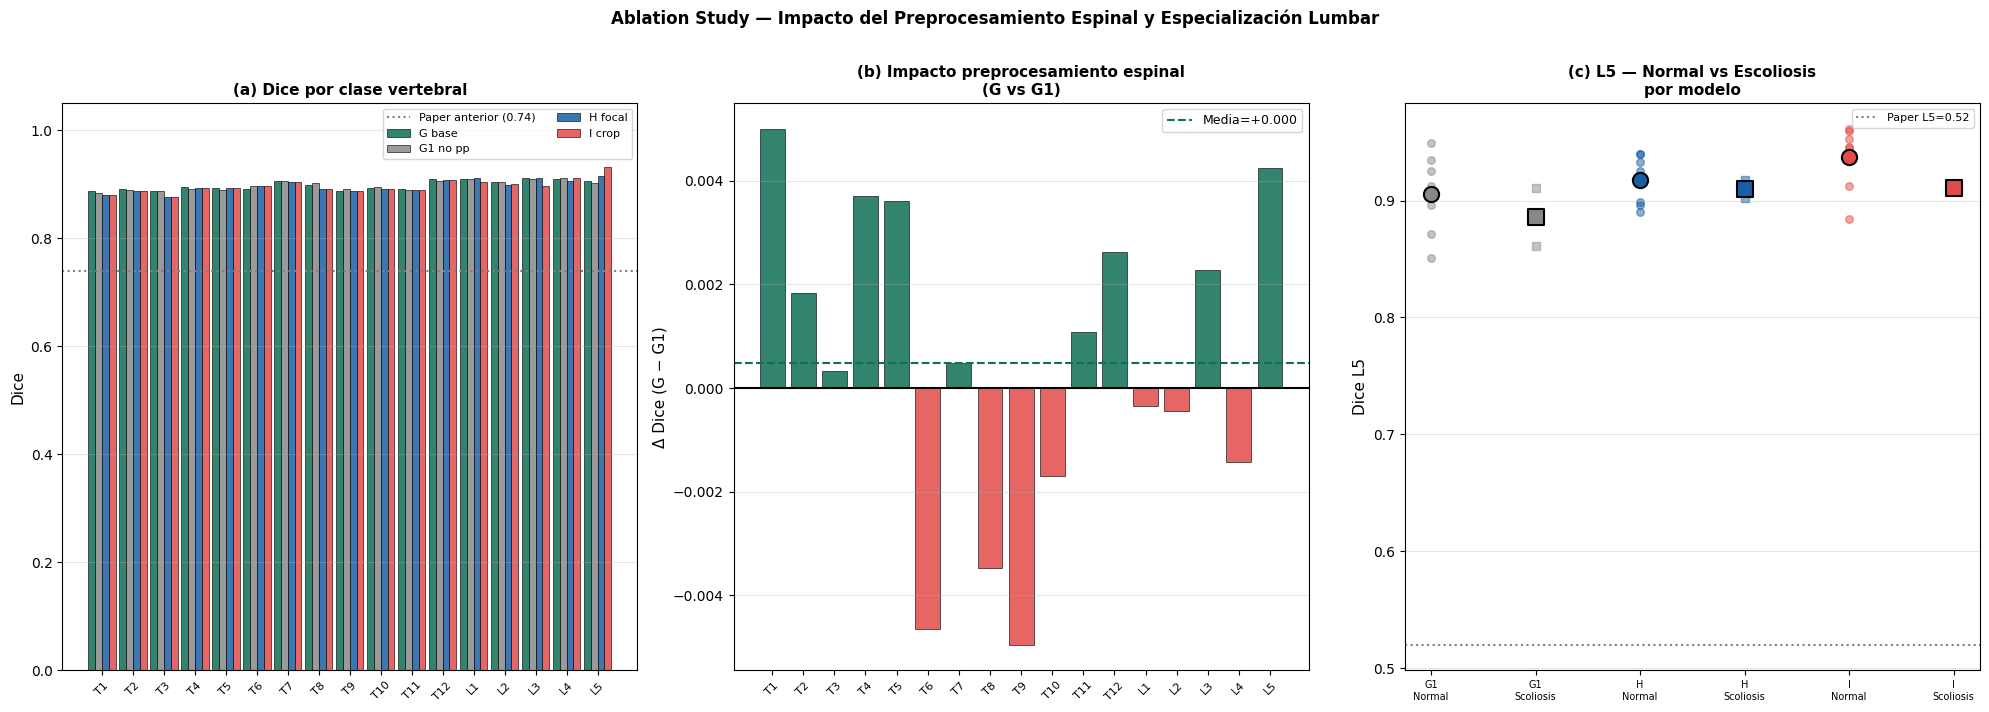

✔ Figura guardada


In [18]:
# ── Figura comparativa estilo paper ──────────────────────────
fig,axes=plt.subplots(1,3,figsize=(20,7))
fig.patch.set_facecolor('white')
x=np.arange(NUM_CLASSES); w=0.22
colors={'G':'#0F6E56','G1':'#888888','H':'#185FA5','I':'#E24B4A'}

# Panel 1: Dice por clase — los 4 modelos
for off,(lbl,col,vals) in enumerate([
    ('G base',  colors['G'],  [r['dice_G']  for r in rows]),
    ('G1 no pp',colors['G1'], [r['dice_G1'] for r in rows]),
    ('H focal', colors['H'],  [r['dice_H']  for r in rows]),
    ('I crop',  colors['I'],  [r['dice_I']  for r in rows]),
]):
    axes[0].bar(x+(off-1.5)*w,vals,w,label=lbl,color=col,alpha=0.85,edgecolor='k',lw=0.5)
axes[0].axhline(0.74,color='gray',ls=':',lw=1.5,label='Paper anterior (0.74)')
axes[0].set_xticks(x); axes[0].set_xticklabels(CLASS_NAMES,rotation=45,fontsize=8)
axes[0].set_ylabel('Dice',fontsize=11); axes[0].set_ylim(0,1.05)
axes[0].set_title('(a) Dice por clase vertebral',fontsize=11,fontweight='bold')
axes[0].legend(fontsize=8,ncol=2); axes[0].grid(axis='y',alpha=0.3)

# Panel 2: Delta G1→G (impacto preprocesamiento)
delta_preproc=[r['dice_G']-r['dice_G1'] for r in rows]
axes[1].bar(x,delta_preproc,
            color=[colors['G'] if d>=0 else '#E24B4A' for d in delta_preproc],
            edgecolor='k',lw=0.5,alpha=0.85)
axes[1].axhline(0,color='black',lw=1.5)
axes[1].axhline(np.mean(delta_preproc),color=colors['G'],ls='--',lw=1.5,
                label=f'Media={np.mean(delta_preproc):+.3f}')
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASS_NAMES,rotation=45,fontsize=8)
axes[1].set_ylabel('Δ Dice (G − G1)',fontsize=11)
axes[1].set_title('(b) Impacto preprocesamiento espinal\n(G vs G1)',
                  fontsize=11,fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(axis='y',alpha=0.3)

# Panel 3: L5 comparativa + análisis Normal vs Escoliosis
l5_data={
    'G' : pd.DataFrame(l5_g  if 'l5_g'  in dir() else []),
    'G1': pd.DataFrame(l5_g1),
    'H' : pd.DataFrame(l5_h),
    'I' : pd.DataFrame(l5_i),
}
for lbl,col in [('G',colors['G']),('G1',colors['G1']),
                ('H',colors['H']),('I',colors['I'])]:
    df_l5=l5_data[lbl]
    if len(df_l5)==0: continue
    for split,marker in [('Normal','o'),('Scoliosis','s')]:
        sub=df_l5[df_l5['split']==split]['dice']
        if len(sub)==0: continue
        axes[2].scatter([f'{lbl}\n{split}']*len(sub),sub,
                        color=col,alpha=0.5,s=30,marker=marker)
        axes[2].scatter([f'{lbl}\n{split}'],[sub.mean()],
                        color=col,s=120,marker=marker,
                        edgecolors='black',lw=1.5,zorder=5)
axes[2].axhline(0.52,color='gray',ls=':',lw=1.5,label='Paper L5=0.52')
axes[2].set_ylabel('Dice L5',fontsize=11)
axes[2].set_title('(c) L5 — Normal vs Escoliosis\npor modelo',
                  fontsize=11,fontweight='bold')
axes[2].legend(fontsize=8); axes[2].grid(axis='y',alpha=0.3)
axes[2].tick_params(axis='x',labelsize=7)

plt.suptitle('Ablation Study — Impacto del Preprocesamiento Espinal y Especialización Lumbar',
             fontsize=12,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig(str(DRIVE_ROOT/'models'/'ablation_G1_H_I.png'),
            dpi=200,bbox_inches='tight',facecolor='white')
plt.show()
print('✔ Figura guardada')

In [19]:
# Guardar todos los modelos en Drive
import shutil
save_dir=DRIVE_ROOT/'models'/'ablation'
save_dir.mkdir(exist_ok=True)

for name in ['G1','H','I']:
    src=CKPT_DIR/f'medsam_{name}_best.pth'
    if src.exists():
        shutil.copy(src, save_dir/f'medsam_{name}_best.pth')
        print(f'✔ {name} guardado')

# Resumen final
print('\n'+'='*65)
print('RESUMEN ABLATION STUDY')
print('='*65)
print(f'''
Pregunta 1: ¿Aporta el preprocesamiento espinal?
  G  (con preproc) : {mg:.4f}
  G1 (sin preproc) : {mg1:.4f}
  Δ  (G − G1)      : {mg-mg1:+.4f}  → {'SÍ aporta' if mg>mg1 else 'NO aporta'}

Pregunta 2: ¿Mejora L5 con Focal Loss?
  G  L5 Dice : {dice_g_v.get(16,0.):.4f}
  H  L5 Dice : {np.mean(dice_h[16]) if dice_h[16] else 0.:.4f}
  Δ  (H − G) : {(np.mean(dice_h[16]) if dice_h[16] else 0.)-(dice_g_v.get(16,0.)):+.4f}
  Global H   : {mh:.4f}  Δ vs G: {mh-mg:+.4f}

Pregunta 3: ¿Aporta el crop lumbar?
  H  L5 Dice : {np.mean(dice_h[16]) if dice_h[16] else 0.:.4f}
  I  L5 Dice : {np.mean(dice_i[16]) if dice_i[16] else 0.:.4f}
  Δ  (I − H) : {(np.mean(dice_i[16]) if dice_i[16] else 0.)-(np.mean(dice_h[16]) if dice_h[16] else 0.):+.4f}
  Global I   : {mi:.4f}  Δ vs G: {mi-mg:+.4f}

Paper anterior: 0.7400
''')
print('='*65)

✔ G1 guardado
✔ H guardado
✔ I guardado

RESUMEN ABLATION STUDY

Pregunta 1: ¿Aporta el preprocesamiento espinal?
  G  (con preproc) : 0.8985
  G1 (sin preproc) : 0.8980
  Δ  (G − G1)      : +0.0005  → SÍ aporta

Pregunta 2: ¿Mejora L5 con Focal Loss?
  G  L5 Dice : 0.9058
  H  L5 Dice : 0.9161
  Δ  (H − G) : +0.0102
  Global H   : 0.8966  Δ vs G: -0.0020

Pregunta 3: ¿Aporta el crop lumbar?
  H  L5 Dice : 0.9161
  I  L5 Dice : 0.9323
  Δ  (I − H) : +0.0163
  Global I   : 0.8966  Δ vs G: -0.0019

Paper anterior: 0.7400

